In [2]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

### Perform a basic stock screening using macrotrends
* Market cap $10-50 Billion
* 3,5, 10 year CAGR between 10-50%
* Current P/E between 10-30
* Current P/B between 2-5
* Current ROE >5


In [5]:
# Above screening yielded 10 stocks:
stocks = ['SNE', 'CMI', 'URI', 'PKI', 'BC', 'BLDR', 'EVR', 'ABG', 'IESC', 'LAKE']

# For some reason SNE doesn't appear - investigate later for now just remove it
stocks = ['CMI', 'URI', 'PKI', 'BC', 'BLDR', 'EVR', 'ABG', 'IESC', 'LAKE']

# Use the Alpha Vantage downloaded data since YFinance is no more...
master = pd.read_csv('tickers-master-long.csv', parse_dates=['timestamp']).set_index(['ticker','timestamp'])
data = master.loc[ stocks ].unstack(level=0)
prices = data['adjusted close']
prices

ticker,CMI,URI,PKI,BC,BLDR,EVR,ABG,IESC,LAKE
timestamp,,,,,,,,,
2022-04-27,194.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-22,199.20,314.67,152.5900,76.13,61.41,107.34,160.51,36.48,17.01
2022-04-14,195.94,331.07,161.3492,75.71,61.16,106.12,153.66,38.64,18.53
2022-04-08,194.69,317.05,172.4143,75.53,59.86,107.71,156.57,38.04,19.48
2022-04-01,201.03,354.00,171.4947,80.28,64.20,111.80,157.86,40.18,19.14
...,...,...,...,...,...,...,...,...,...
2022-04-29,NaN,316.52,146.6100,NaN,NaN,105.75,NaN,29.30,16.18
2022-05-09,NaN,NaN,142.4500,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-26,NaN,NaN,NaN,74.48,61.36,NaN,NaN,NaN,NaN


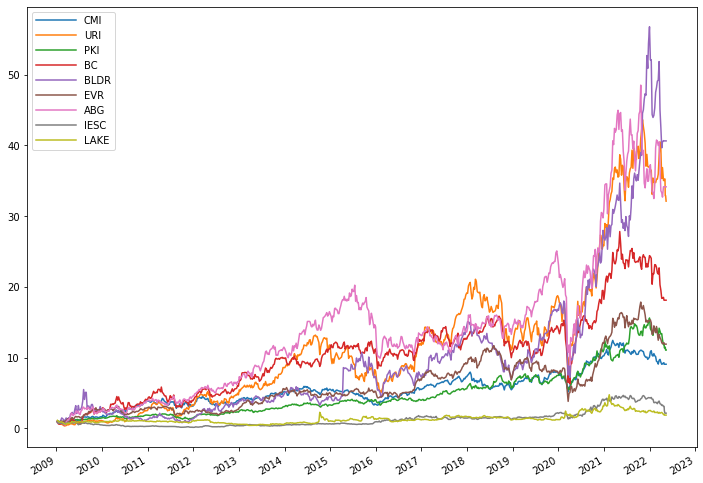

In [8]:
ret = prices.sort_index()

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'tab:silver', 'tab:yellow', 'tab:black' ]
fig, ax = plt.subplots(figsize=(12,9))

# Include a method for selecting the start date, since that affects the results a lot for stocks which have NaN at beginning
start_date = '2009-01-01'
data_to_plot = ret.loc[ ret.index > start_date ]
returns = data_to_plot.pct_change()
daily_cum_ret = (1+returns).cumprod()
for l,i in enumerate(stocks):
    col = colors[l]
    ax.plot(daily_cum_ret.index, daily_cum_ret[i], color=col, label=i)
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
fig.autofmt_xdate()
plt.legend(handlelength=4)
plt.show()


ticker           CMI        URI        PKI         BC       BLDR        EVR  \
timestamp                                                                     
2022-05-13  9.077781  32.120267  11.073539  18.127829  40.635762  11.918313   

ticker            ABG      IESC      LAKE  
timestamp                                  
2022-05-13  34.151064  2.163527  1.889384  
ticker           URI       PKI        BC      BLDR       EVR       ABG
timestamp                                                             
2022-05-13  1.683044  1.873977  1.397051  2.693591  1.283033  2.411871


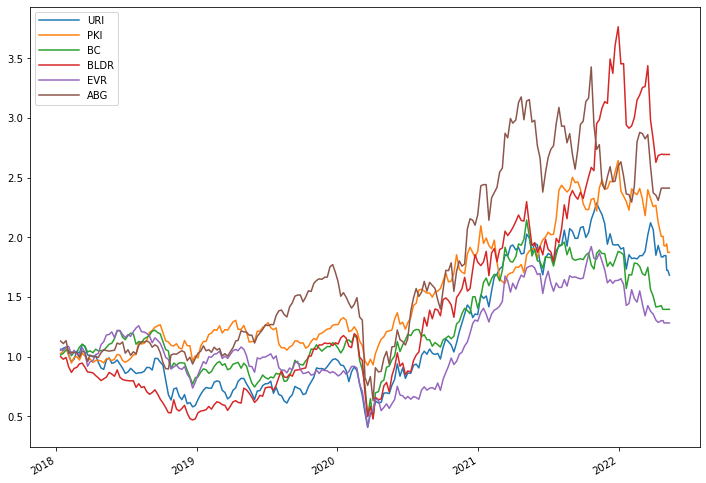

In [9]:
# Repeat but using the above chart filter out the stocks that in the end had the lowest long-term return
final = daily_cum_ret[-1:]
print(final)

# Manually filter because I can't work out how to filter columns based on a condition :)
best = [ 'URI', 'PKI', 'BC', 'BLDR', 'EVR', 'ABG']
top = ret[best]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'tab:silver', 'tab:yellow', 'tab:black' ]
fig, ax = plt.subplots(figsize=(12,9))

# Include a method for selecting the start date, since that affects the results a lot for stocks which have NaN at beginning
start_date = '2018-01-01'
data_to_plot = top.loc[ top.index > start_date ]
returns = data_to_plot.pct_change()
top_daily_cum_ret = (1+returns).cumprod()
final = top_daily_cum_ret[-1:]
print(final)
for l,i in enumerate(best):
    col = colors[l]
    ax.plot(top_daily_cum_ret.index, top_daily_cum_ret[i], color=col, label=i)
ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
fig.autofmt_xdate()
plt.legend(handlelength=4)
plt.show()

In [2]:
# Quick digression to look at how volatilty affects expected return
# From https://www.investopedia.com/articles/04/021804.asp
# Counter-intuitive, but the presence of volatility in returns erodes value
# An average return of 10% pa will NOT yield 10% pa returns if the annual returns are volatile
import numpy as np 

# random returns over 5 years, average = 10%
returns = np.array([15, 0, 20, -5, 20])
mean = returns.mean()
std = returns.std()
print("Mean:", mean)
print("std:", std)

# Variance is the mean of the sum of squares of the difference between each value and the mean value
variance_manual = (25 + 100 + 100 + 225 + 100) / 5
print("Manually calculated:", variance_manual)
print("Using var function:", returns.var())

# Total return after all 5 years
total_ret = (1 + returns/100).cumprod()[-1]
print("Total return:", total_ret)


# Annualized
annualized = (1 + total_ret) ** (1/5) - 1
print("Annualized:\n", annualized)

Mean: 10.0
std: 10.488088481701515
Manually calculated: 110.0
Using var function: 110.0
Total return: 1.5732
Annualized:
 0.20807725720914205


In [11]:
# Something different - equally wasteful of time???
# Discover the industries and sectors for all my favourite stocks
# Then look for the slightly smaller companies in the same sectors
# These might be the ones that grow the most in the next ten years
# Assumption here is that the FAANMG stocks are very large and might not be able to keep up the growth
# But maybe the next generation can
#
# From macrotrends.com:
# ADBE:		Computer and Technology		Computer Software
# FB:		Computer and Technology		Internet Services
# AAPL:		Computer and Technology		Computers - Minicomputers
# NVDA:		Computer and Technology		Semiconductor - General
overview = pd.read_csv('av-overview.csv', parse_dates=['LatestQuarter'])

overview[ overview['Sector'] == 'TECHNOLOGY']['Industry'].value_counts()
overview['Sector'].value_counts()
overview['Industry'].value_counts()
# overview[ overview['ticker'] =='NVDA']
# overview[ overview['Industry'] == 'SEMICONDUCTORS & RELATED DEVICES']

BLANK CHECKS                                            2045
PHARMACEUTICAL PREPARATIONS                              611
GENERAL                                                  457
REAL ESTATE INVESTMENT TRUSTS                            375
SERVICES-PREPACKAGED SOFTWARE                            249
                                                        ... 
UNSUPPORTED PLASTICS FILM & SHEET                          1
OFFICE FURNITURE                                           1
WHOLESALE-JEWELRY, WATCHES, PRECIOUS STONES & METALS       1
RETAIL-CONVENIENCE STORES                                  1
DOLLS & STUFFED TOYS                                       1
Name: Industry, Length: 399, dtype: int64